In [37]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df= pd.read_csv('../processed_data/search_converted.csv')
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

df.head()


,participant_no,week_no,url,query,data,type,task,goal,source,content,format
0,102,Week 1,https://www.google.com/search?q=foods to avoid...,foods to avoid while losing body fat,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
1,102,Week 1,https://www.google.com/search?q=foods to eat t...,foods to eat that help lose weight,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
2,102,Week 1,https://www.google.com/search?q=foods to eat t...,foods to eat that help lose weight,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
3,102,Week 1,https://www.google.com/search?q=vegan foods to...,vegan foods to eat that help lose weight,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
4,102,Week 1,https://www.google.com/search?q=is avocado foo...,is avocado food or bad,Q,normative,evaluate,decision making,NaN,NaN,NaN



## Basic weekly volume


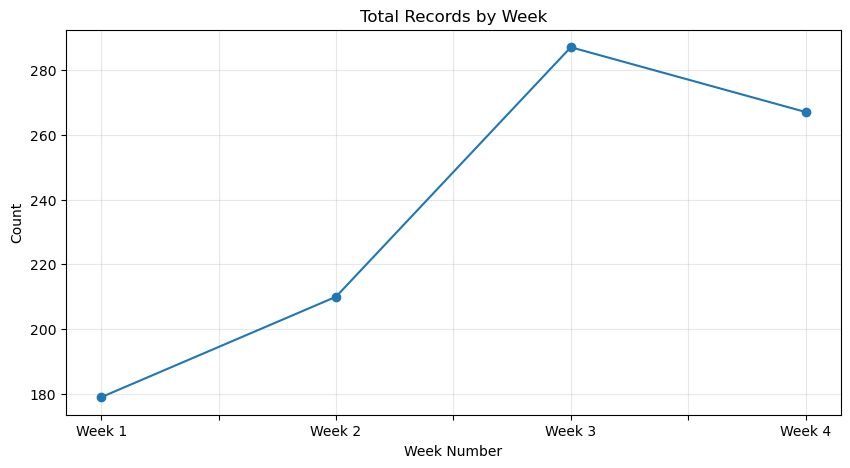

,count
week_no,
Week 1,179
Week 2,210
Week 3,287
Week 4,267


In [38]:

weekly_counts = (
    df.groupby('week_no')
      .size()
      .sort_index()
)

plt.figure(figsize=(10, 5))
weekly_counts.plot(marker='o')
plt.title('Total Records by Week')
plt.xlabel('Week Number')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

weekly_counts.to_frame('count')



## Trend by `goal`,`type`,task`


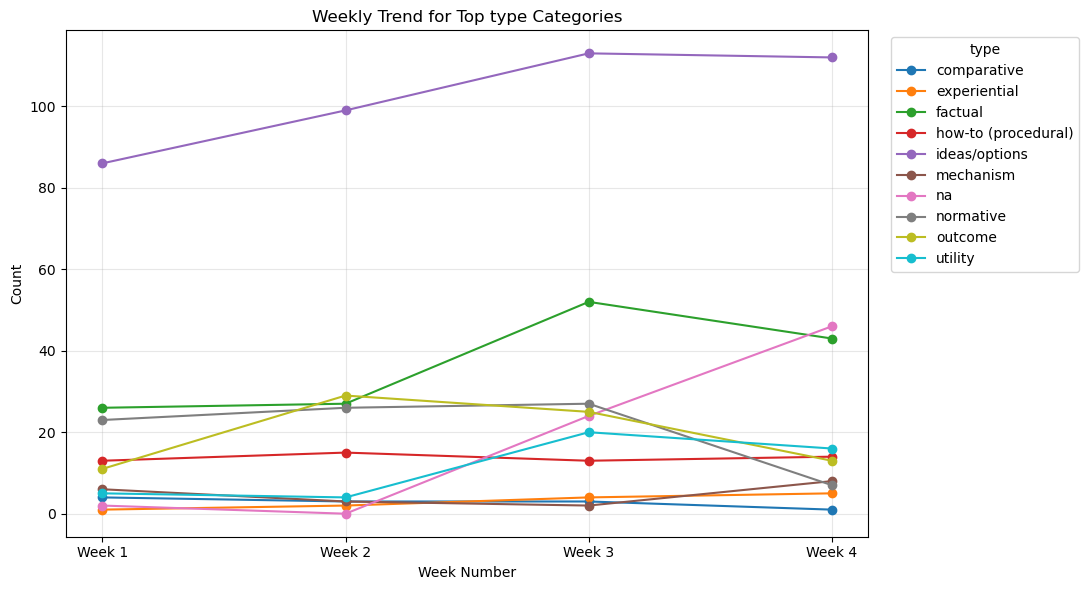

type,comparative,experiential,factual,how-to (procedural),ideas/options,mechanism,na,normative,outcome,utility
week_no,,,,,,,,,,
Week 1,4,1,26,13,86,6,2,23,11,5
Week 2,3,2,27,15,99,3,0,26,29,4
Week 3,3,4,52,13,113,2,24,27,25,20
Week 4,1,5,43,14,112,8,46,7,13,16


In [39]:

top_types = df['type'].dropna().value_counts().head(10).index.tolist()

type_week = (
    df[df['type'].isin(top_types)]
      .groupby(['week_no', 'type'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

plt.figure(figsize=(11, 6))
for col in type_week.columns:
    plt.plot(type_week.index, type_week[col], marker='o', label=col)

plt.title('Weekly Trend for Top type Categories')
plt.xlabel('Week Number')
plt.ylabel('Count')
plt.legend(title='type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

type_week

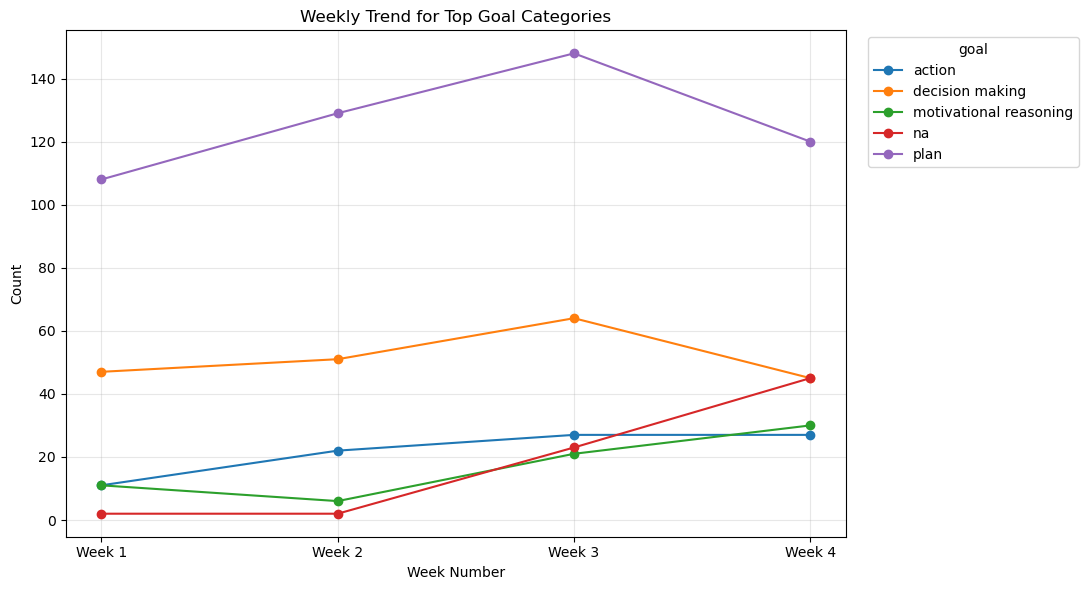

goal,action,decision making,motivational reasoning,na,plan
week_no,,,,,
Week 1,11,47,11,2,108
Week 2,22,51,6,2,129
Week 3,27,64,21,23,148
Week 4,27,45,30,45,120


In [40]:

top_goals = df['goal'].dropna().value_counts().head(8).index.tolist()

goal_week = (
    df[df['goal'].isin(top_goals)]
      .groupby(['week_no', 'goal'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

plt.figure(figsize=(11, 6))
for col in goal_week.columns:
    plt.plot(goal_week.index, goal_week[col], marker='o', label=col)

plt.title('Weekly Trend for Top Goal Categories')
plt.xlabel('Week Number')
plt.ylabel('Count')
plt.legend(title='goal', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

goal_week


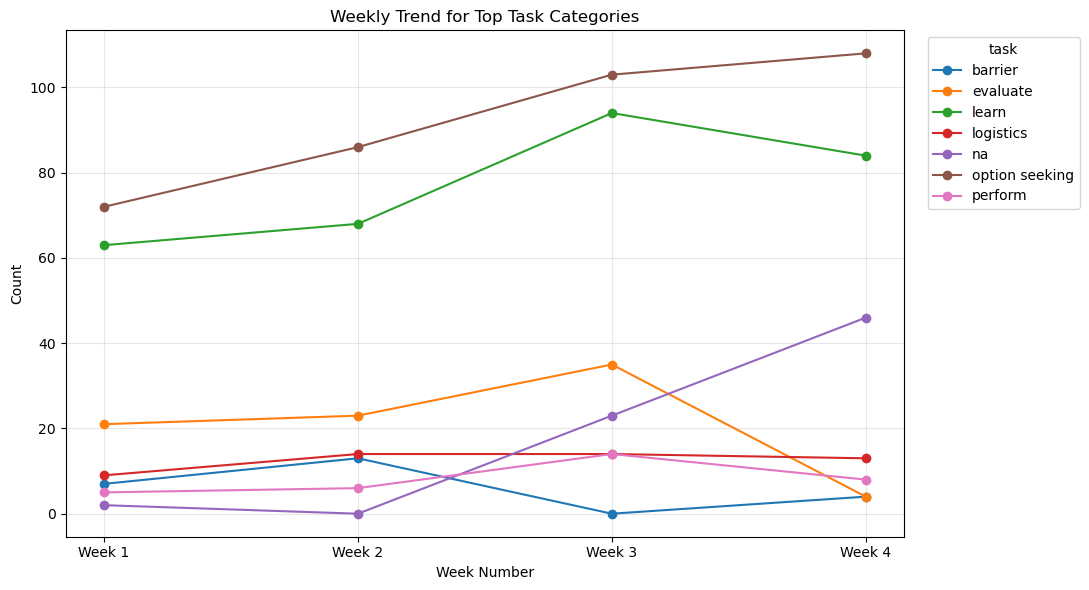

task,barrier,evaluate,learn,logistics,na,option seeking,perform
week_no,,,,,,,
Week 1,7,21,63,9,2,72,5
Week 2,13,23,68,14,0,86,6
Week 3,0,35,94,14,23,103,14
Week 4,4,4,84,13,46,108,8


In [41]:

top_tasks = df['task'].dropna().value_counts().head(10).index.tolist()

task_week = (
    df[df['task'].isin(top_tasks)]
      .groupby(['week_no', 'task'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

plt.figure(figsize=(11, 6))
for col in task_week.columns:
    plt.plot(task_week.index, task_week[col], marker='o', label=col)

plt.title('Weekly Trend for Top Task Categories')
plt.xlabel('Week Number')
plt.ylabel('Count')
plt.legend(title='task', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

task_week



## Query-based exploration using the `query` column

For text analysis, we should use **`query` instead of `url`**.  
A URL may contain routing or website structure, but the query text directly reflects what the user wanted.

This section focuses only on rows where the query text is present.


In [42]:

query_df = df.dropna(subset=['query', 'week_no']).copy()

print("Rows with usable query text:", query_df.shape[0])
query_df[['week_no', 'query', 'data', 'task', 'goal']].head()


Rows with usable query text: 943


,week_no,query,data,task,goal
0,Week 1,foods to avoid while losing body fat,Q,option seeking,plan
1,Week 1,foods to eat that help lose weight,Q,option seeking,plan
2,Week 1,foods to eat that help lose weight,Q,option seeking,plan
3,Week 1,vegan foods to eat that help lose weight,Q,option seeking,plan
4,Week 1,is avocado food or bad,Q,evaluate,decision making



### Average query length by week

This gives a rough measure of how detailed the weekly search behavior was.  
Longer queries may suggest more specific intent or more constrained information needs.


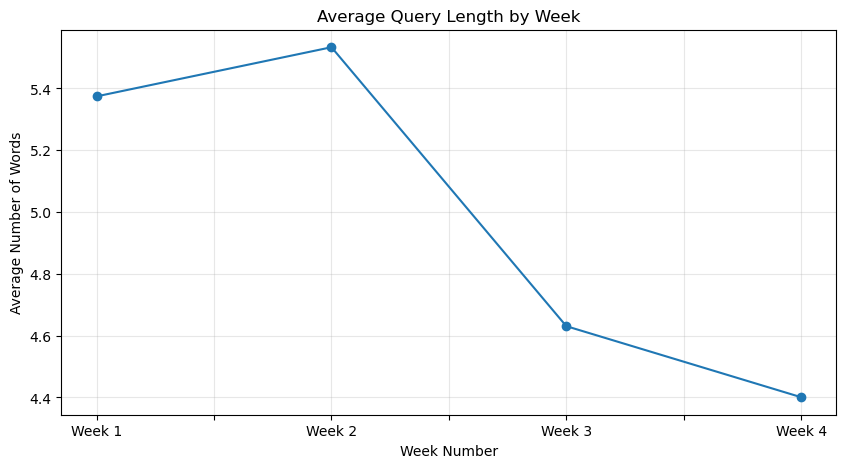

,avg_query_length
week_no,
Week 1,5.374302
Week 2,5.533333
Week 3,4.630662
Week 4,4.400749


In [43]:

query_df['query_len'] = query_df['query'].astype(str).str.split().str.len()

avg_query_len_week = (
    query_df.groupby('week_no')['query_len']
            .mean()
            .sort_index()
)

plt.figure(figsize=(10, 5))
avg_query_len_week.plot(marker='o')
plt.title('Average Query Length by Week')
plt.xlabel('Week Number')
plt.ylabel('Average Number of Words')
plt.grid(True, alpha=0.3)
plt.show()

avg_query_len_week.to_frame('avg_query_length')



## Compact summary tables for `type`, `task`, and `goal`

These tables show the weekly counts in matrix form, which is useful if you want the exact numbers behind the plots.


In [44]:

type_week_table = (
    df.dropna(subset=['type', 'week_no'])
      .groupby(['week_no', 'type'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
type_week_table


type,comparative,experiential,factual,how-to (procedural),how-to (psyc),ideas/options,mechanism,na,normative,outcome,utility
week_no,,,,,,,,,,,
Week 1,4,1,26,13,2,86,6,2,23,11,5
Week 2,3,2,27,15,2,99,3,0,26,29,4
Week 3,3,4,52,13,0,113,2,24,27,25,20
Week 4,1,5,43,14,2,112,8,46,7,13,16


In [45]:

task_week_table = (
    df.dropna(subset=['task', 'week_no'])
      .groupby(['week_no', 'task'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
task_week_table


task,barrier,evaluate,learn,logistics,na,option seeking,perform
week_no,,,,,,,
Week 1,7,21,63,9,2,72,5
Week 2,13,23,68,14,0,86,6
Week 3,0,35,94,14,23,103,14
Week 4,4,4,84,13,46,108,8


In [46]:

goal_week_table = (
    df.dropna(subset=['goal', 'week_no'])
      .groupby(['week_no', 'goal'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
goal_week_table


goal,action,decision making,motivational reasoning,na,plan
week_no,,,,,
Week 1,11,47,11,2,108
Week 2,22,51,6,2,129
Week 3,27,64,21,23,148
Week 4,27,45,30,45,120
